In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux


import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import dynesty
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



In [ ]:
import stableemrifisher
stableemrifisher.__file__

'/nfs/home/svu/e1498138/localgit/Fisher/StableEMRIFisher/stableemrifisher/__init__.py'

In [3]:
from tqdm import tqdm
from stableemrifisher.fisher.fisher import StableEMRIFisher
from stableemrifisher.utils import inner_product

startup


In [4]:
# GPU configuration
use_gpu = True
dt = 10     # Time step
T = 2   # Total time

In [5]:
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
        "err": 1e-15  # Error tolerance 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True
}

In [6]:
gwf = GWfuncs.GravWaveAnalysis(T, dt)

In [7]:
waveform_class = FastKerrEccentricEquatorialFlux
waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                             amplitude_kwargs=amplitude_kwargs,
                             Ylm_kwargs=Ylm_kwargs,
                             sum_kwargs=sum_kwargs,
                             use_gpu=use_gpu)

 
#waveform generator setup
waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(frame='detector')

In [8]:
gew_waveform_gen = GenerateEMRIWaveform(
    waveform_class, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

In [9]:
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 
e0 = 0.4
xI0 = 1.0
dist = 0.9  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5



In [10]:
from lisatools.sensitivity import get_sensitivity, CornishLISASens
sef = StableEMRIFisher(
    waveform_class=waveform_class,
    waveform_class_kwargs=waveform_class_kwargs,
    waveform_generator=waveform_generator,
    waveform_generator_kwargs=waveform_generator_kwargs,
    stats_for_nerds=True,
    use_gpu=use_gpu,
    deriv_type='stable',
    noise_model=get_sensitivity,
    noise_kwargs={'sens_fn': CornishLISASens, 'return_type': 'PSD'},
    channels=["A"]
)

# Fisher calculation parameters
der_order = 4
Ndelta = 8
stability_plot = False
param_names = ['m1', 'm2', 'a', 'p0', 'e0']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]


In [11]:
Fisher = sef(*pars_list, param_names = param_names, 
             T = T, dt = dt, 
             der_order = der_order, 
             Ndelta = Ndelta, 
             stability_plot = stability_plot,
            #  delta_range = delta_range,
            live_dangerously = False)

T:  2 dt:  10
Body is not plunging, Fisher should be stable.
wave ndim: 2
Computing SNR for parameters: (1000000.0, 30.0, 0.7, 11.7, 0.4, 1.0, 0.9, 3.141592653589793, 0.0, 0.0, 0.0, 0.4, 0.0, 0.5)
Waveform Generated. SNR: 97.08971381678604
calculating stable deltas...
Gamma_ii for m1: 39506.48757141684
Gamma_ii for m1: 39506.487572302496
Gamma_ii for m1: 39506.48757232925
Gamma_ii for m1: 39506.48758033239
Gamma_ii for m1: 39506.48755615897
Gamma_ii for m1: 39506.487540024005
Gamma_ii for m1: 39506.4870803088
Gamma_ii for m1: 39506.49291562193
[np.float64(2.2418056351073528e-11), np.float64(6.771975387174389e-13), np.float64(2.0257783306461247e-10), np.float64(6.118847186380252e-10), np.float64(4.0841310273436116e-10), np.float64(1.1636448628395995e-08), np.float64(1.4770516694930585e-07)]
1
Gamma_ii for m2: 4349438615891.603
Gamma_ii for m2: 4349438615891.8486
Gamma_ii for m2: 4349438615546.1177
Gamma_ii for m2: 4349438610648.3745
Gamma_ii for m2: 4349438615235.903
Gamma_ii for m2: 43

In [12]:
Fisher.shape

(5, 5)

In [13]:
# CHAIN RULE FOR FISHER
J_mx = np.eye(5)
J_mx[0, 0] = m1
J_mx[1, 1] = m2

Fisher_scaled = J_mx.T @ Fisher @ J_mx

(<Figure size 2000x2000 with 15 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

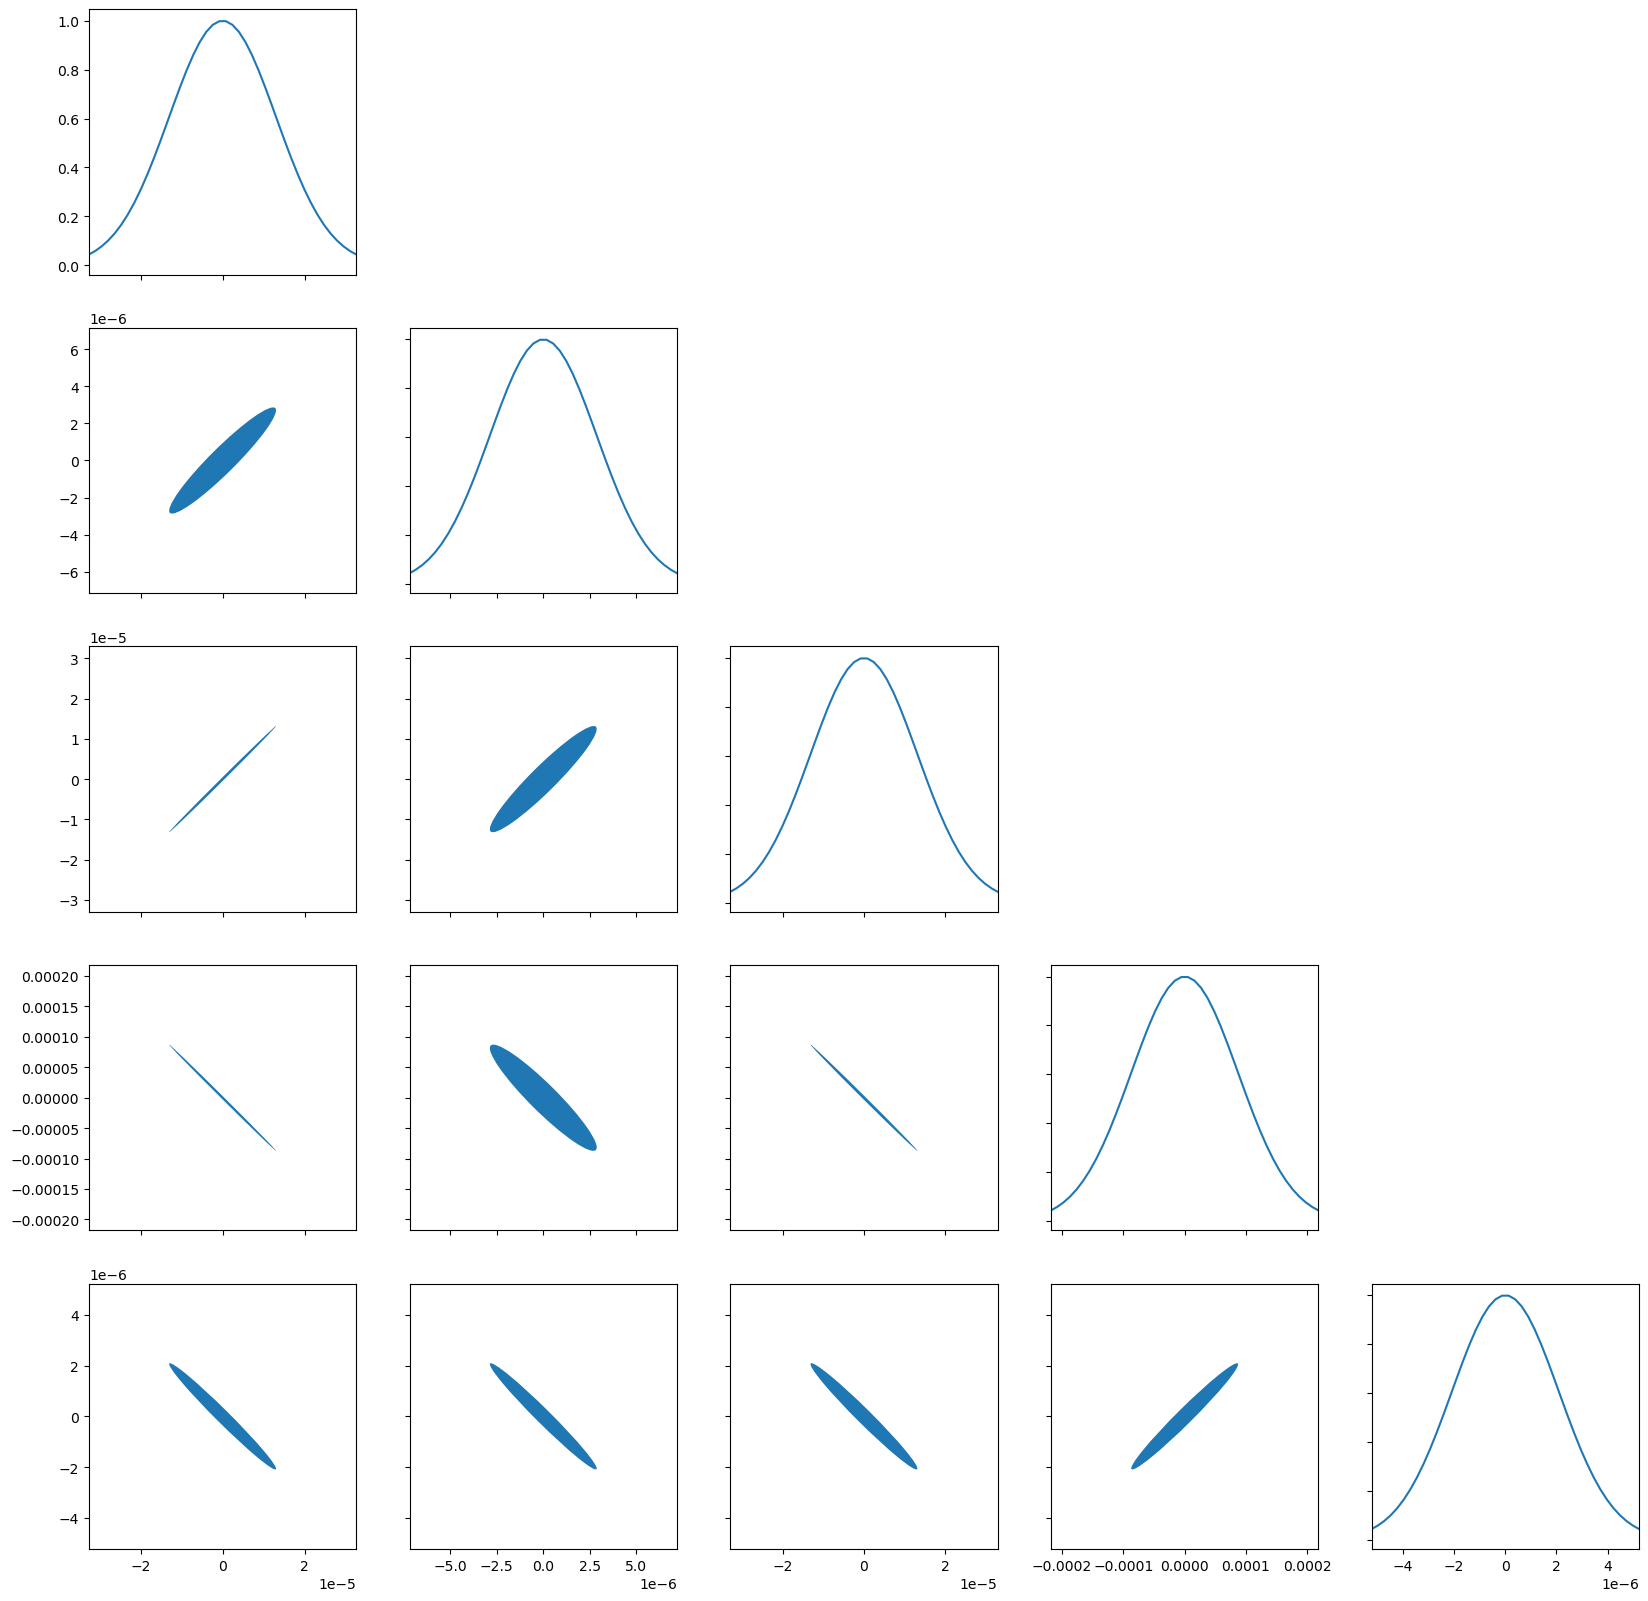

In [14]:
from stableemrifisher.plot import CovEllipsePlot

CovEllipsePlot(np.linalg.inv(Fisher_scaled))

In [15]:
cov = np.linalg.inv(Fisher_scaled)
cov

array([[ 1.69970756e-10,  3.53247902e-11,  1.71993208e-10,
        -1.13673764e-09, -2.68464902e-11],
       [ 3.53247902e-11,  8.22669319e-12,  3.57143606e-11,
        -2.33722961e-10, -5.88656280e-12],
       [ 1.71993208e-10,  3.57143606e-11,  1.74265932e-10,
        -1.15073184e-09, -2.70875143e-11],
       [-1.13673764e-09, -2.33722961e-10, -1.15073184e-09,
         7.61017614e-09,  1.78548836e-10],
       [-2.68464902e-11, -5.88656280e-12, -2.70875143e-11,
         1.78548836e-10,  4.36996828e-12]])

In [16]:
import pickle
with open('cov_matrix_snr96.pkl', 'wb') as f:
    pickle.dump(cov, f)

# Check Waveform

In [17]:
params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]


In [18]:
h = gew_waveform_gen(*params, T=T, dt=dt)


In [19]:
gwf.rhostat(h)

array(97.08971382)

In [20]:
h_short = gew_waveform_gen(*params, T=1/12, dt=dt)


In [21]:
gwf_short = GWfuncs.GravWaveAnalysis(T=1/12,dt=10)

In [22]:
gwf_short.rhostat(h_short)

array(5.97163341)